# Phase 4 — integrated analysis notebook

One notebook for all three RQs so we're all working in the same file. Runs top to bottom on `data_clean.csv`. Steps 1-3 set up (population, Table 1, shared imputation), Step 4 = RQ1, Step 5 = RQ2 + blinding, Steps 6-8 = RQ3, Step 9 report figures, Step 10 report text.

Conventions:

- `pain_score_diff = baseline - final`, positive = improvement
- MCID = 1.6 pts (Han et al., BJSM 2024;58:1539-50; WOMAC pain on its native 0-20 scale, no rescaling). Exercise-trial derived, so treated as a benchmark rather than a decision rule; MCID-dependent results rerun at 1.0 / 1.6 / 2.0 / 2.5 in 4e and 6b
- imputation is built once (Step 3) and reused for RQ1 and RQ3, so benefit and harm rest on the same missing-data assumptions
- don't overwrite `data_clean.csv`


In [1]:
%matplotlib inline
import numpy as np, pandas as pd
from scipy import stats
import matplotlib.pyplot as plt, seaborn as sns
try:
    import statsmodels.api as sm, statsmodels.formula.api as smf
    HAVE_SM = True
except Exception:
    from sklearn.linear_model import LinearRegression, LogisticRegression
    HAVE_SM = False

sns.set_theme(style="whitegrid", context="notebook")
RNG  = np.random.default_rng(42)
MCID = 1.6          # WOMAC pain (0-20) MCID. Han et al. BJSM 2024;58:1539-50 report
                    # MCID = 1.6 for the WOMAC pain subscale on its native 0-20 scale
                    # (no rescaling needed). Derived from exercise trials - see caveat.
MCID_ALT = [1.0, 1.6, 2.0, 2.5]   # thresholds for the MCID sensitivity analysis
M    = 20           # number of imputations

df = pd.read_csv("data_clean.csv", index_col=0)
df["arm"] = df.treatment_group.map({0:"Control", 1:"Intervention"})
cc = df.dropna(subset=["pain_score_final"]).copy()      # complete-case set
palette = {"Control":"#4C72B0", "Intervention":"#DD8452"}
FULL_FORM = ("pain_score_final ~ treatment_group + pain_score_baseline + age "
             "+ C(gender) + bmi + C(trial_centre)")
print(f"Randomised {len(df)} | complete 6-month outcome {len(cc)} | statsmodels={HAVE_SM}")


# quick integrity check: pain_score_diff was recomputed during cleaning after ~25% of the
# supplied values turned out inconsistent - make sure this file has the corrected version
dev = (df.pain_score_baseline - df.pain_score_final) - df.pain_score_diff
assert dev.abs().max() < 1e-9, "pain_score_diff inconsistent with its components!"
print("pain_score_diff consistent with baseline - final (max deviation "
      f"{dev.abs().max():.1e}) - recomputed change score confirmed")

Randomised 2500 | complete 6-month outcome 2240 | statsmodels=True
pain_score_diff consistent with baseline - final (max deviation 1.8e-15) - recomputed change score confirmed


In [2]:
# ---- statistics helpers: use statsmodels if present, else numpy equivalents ----
def _dmat(data, terms):
    """Build a design matrix. terms: list of (col, kind) kind in {'num','cat'}."""
    X=[np.ones(len(data))]; names=["Intercept"]
    for col,kind in terms:
        if kind=="num":
            X.append(data[col].astype(float).values); names.append(col)
        else:
            cats=sorted(data[col].dropna().unique())[1:]      # drop first level
            for c in cats:
                X.append((data[col]==c).astype(float).values); names.append(f"C({col})[{c}]")
    return np.column_stack(X), names

def ols_hc3(data, y, terms, target):
    """OLS with HC3 robust SE. Returns (beta, lo, hi, p, resid, fitted, X)."""
    X,names=_dmat(data,terms); yv=data[y].astype(float).values
    XtXi=np.linalg.pinv(X.T@X); beta=XtXi@X.T@yv
    fitted=X@beta; resid=yv-fitted
    h=np.einsum("ij,jk,ik->i",X,XtXi,X)                        # leverage
    S=(X*(resid/(1-h))[:,None]).T@(X*(resid/(1-h))[:,None])    # HC3 meat
    V=XtXi@S@XtXi; j=names.index(target)
    se=np.sqrt(V[j,j]); b=beta[j]
    p=2*stats.norm.sf(abs(b/se))
    return b, b-1.96*se, b+1.96*se, p, resid, fitted, X

def ols_plain(data, y, terms, target):
    X,names=_dmat(data,terms); yv=data[y].astype(float).values
    XtXi=np.linalg.pinv(X.T@X); beta=XtXi@X.T@yv
    resid=yv-X@beta; n,k=X.shape; s2=resid@resid/(n-k)
    V=s2*XtXi; j=names.index(target); se=np.sqrt(V[j,j]); b=beta[j]
    p=2*stats.t.sf(abs(b/se), n-k)
    return b, se, p, resid, X, beta, names

def breusch_pagan(resid, X):
    u=resid**2; g=u/u.mean()
    bh=np.linalg.pinv(X.T@X)@X.T@g; fit=X@bh
    sse=((fit-g.mean())**2).sum(); lm=sse/2
    return stats.chi2.sf(lm, X.shape[1]-1)
def _wilson_ci(x,n,z=1.96):
    if n==0: return (np.nan,np.nan)
    p=x/n; d=1+z*z/n; ctr=(p+z*z/(2*n))/d; h=z*np.sqrt(p*(1-p)/n+z*z/(4*n*n))/d
    return max(0.0, ctr-h), min(1.0, ctr+h)      # clamp to valid proportion range
def _rd_newcombe(x1,n1,x0,n0,z=1.96):
    """Risk difference (group1 - group0) with Newcombe hybrid-score 95% CI."""
    p1,p0=x1/n1,x0/n0; l1,u1=_wilson_ci(x1,n1,z); l0,u0=_wilson_ci(x0,n0,z); rd=p1-p0
    return rd, rd-np.sqrt((p1-l1)**2+(u0-p0)**2), rd+np.sqrt((u1-p1)**2+(p0-l0)**2)
def _rr_log(x1,n1,x0,n0,z=1.96):
    a,b=(x1,x0) if (x1>0 and x0>0) else (x1+.5,x0+.5)
    n1c,n0c=(n1,n0) if (x1>0 and x0>0) else (n1+1,n0+1)
    rr=(a/n1c)/(b/n0c); se=np.sqrt(1/a-1/n1c+1/b-1/n0c)
    return rr, np.exp(np.log(rr)-z*se), np.exp(np.log(rr)+z*se)

print("stats helpers ready (statsmodels present:", HAVE_SM, ")")


stats helpers ready (statsmodels present: True )


## Step 2 — Analysis population & missingness (CONSORT items 21b, 21c, 22)

In [3]:
for a,g in df.groupby("arm"):
    n,k=len(g), g.pain_score_final.notna().sum()
    print(f"{a:12s}: randomised {n}, analysed {k}, lost to follow-up {n-k} ({100*(n-k)/n:.1f}%)")
print("\nStructural missingness (by design, NEVER imputed):")
for c_ in ["physical_activity","app_interactions"]:
    miss_ctl = df.loc[df.treatment_group==0, c_].isna().sum()
    print(f"  {c_:20s}: missing for {df[c_].isna().sum()} (all {miss_ctl} controls) - device not issued")
print("\nDifferential attrition (13.6% vs 7.1%) -> shared imputation + bounding in Steps 3/4/5.")


Control     : randomised 1232, analysed 1145, lost to follow-up 87 (7.1%)
Intervention: randomised 1268, analysed 1095, lost to follow-up 173 (13.6%)

Structural missingness (by design, NEVER imputed):
  physical_activity   : missing for 1232 (all 1232 controls) - device not issued
  app_interactions    : missing for 1232 (all 1232 controls) - device not issued

Differential attrition (13.6% vs 7.1%) -> shared imputation + bounding in Steps 3/4/5.


### Which covariates predict dropout?

Needed before claiming MAR - whatever predicts missingness has to be in the imputation model (Step 3 includes all of these).

In [4]:
df["missing_final"] = df.pain_score_final.isna().astype(int)

# unadjusted first - simple comparisons of who goes missing
fm = df.groupby("gender").missing_final.mean()
print(f"Unadjusted: dropout {100*fm[1]:.1f}% (F) vs {100*fm[0]:.1f}% (M), "
      f"chi2 p={stats.chi2_contingency(pd.crosstab(df.gender, df.missing_final))[1]:.3f}")
print(f"            baseline pain, missing vs observed: "
      f"{df.loc[df.missing_final==1,'pain_score_baseline'].mean():.2f} vs "
      f"{df.loc[df.missing_final==0,'pain_score_baseline'].mean():.2f}, "
      f"t-test p={stats.ttest_ind(df.loc[df.missing_final==1,'pain_score_baseline'], df.loc[df.missing_final==0,'pain_score_baseline']).pvalue:.3f}")
print("            by centre: " + ", ".join(f"C{k} {100*v:.1f}%" for k,v in df.groupby("trial_centre").missing_final.mean().items()))

# adjusted logistic model - which associations survive together?
if HAVE_SM:
    ml = smf.logit("missing_final ~ treatment_group + gender + age + bmi + pain_score_baseline "
                   "+ n_current_medications + C(trial_centre)", data=df).fit(disp=0)
    ors, cis = np.exp(ml.params), np.exp(ml.conf_int())
    print("\nAdjusted odds of dropout:")
    for k in ml.params.index:
        if k=="Intercept": continue
        print(f"   {k:25s} OR {ors[k]:.2f} ({cis.loc[k,0]:.2f}-{cis.loc[k,1]:.2f})  p={ml.pvalues[k]:.4f}")

print("\narm and centre 3 dominate; lower baseline pain also predicts dropout independently.")
print("the unadjusted sex gap is mostly the gender imbalance showing up via arm.")

Unadjusted: dropout 11.9% (F) vs 8.8% (M), chi2 p=0.014
            baseline pain, missing vs observed: 13.87 vs 14.03, t-test p=0.013
            by centre: C1 6.9%, C2 9.3%, C3 15.1%

Adjusted odds of dropout:
   C(trial_centre)[T.2]      OR 1.39 (0.94-2.05)  p=0.0946
   C(trial_centre)[T.3]      OR 2.44 (1.75-3.39)  p=0.0000
   treatment_group           OR 1.98 (1.49-2.64)  p=0.0000
   gender                    OR 1.19 (0.90-1.57)  p=0.2205
   age                       OR 1.02 (0.99-1.05)  p=0.2128
   bmi                       OR 1.00 (0.93-1.06)  p=0.8830
   pain_score_baseline       OR 0.86 (0.75-0.98)  p=0.0222
   n_current_medications     OR 1.02 (0.95-1.09)  p=0.6314

arm and centre 3 dominate; lower baseline pain also predicts dropout independently.
the unadjusted sex gap is mostly the gender imbalance showing up via arm.


### CONSORT flow diagram

Figure 1 for the report. 5,123 invited is from the brief; everything else computed from the data.

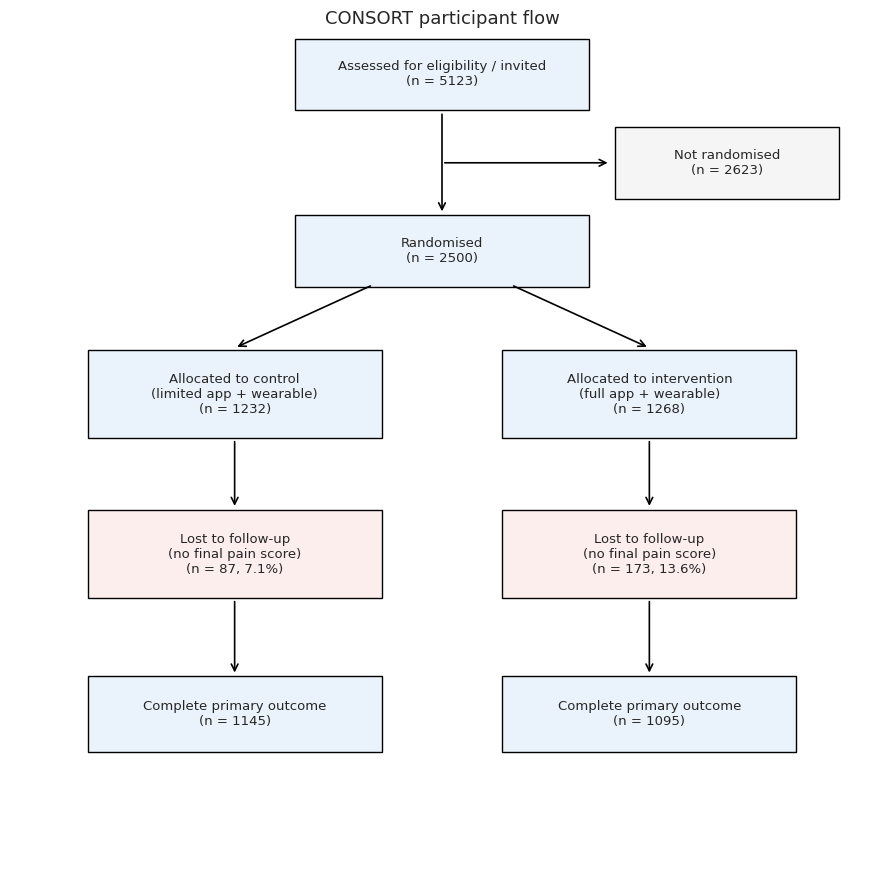

In [5]:
N_INVITED = 5123  # from the study brief

n_ctrl, n_int = (df.treatment_group == 0).sum(), (df.treatment_group == 1).sum()
complete = df.pain_score_final.notna()
n_ctrl_an = (complete & (df.treatment_group == 0)).sum()
n_int_an  = (complete & (df.treatment_group == 1)).sum()

fig, ax = plt.subplots(figsize=(9, 9))
ax.axis("off")

def box(x, y, text, w=0.34, h=0.085, fc="#eaf2fb"):
    ax.add_patch(plt.Rectangle((x - w/2, y - h/2), w, h, facecolor=fc,
                               edgecolor="black", lw=1, zorder=2))
    ax.text(x, y, text, ha="center", va="center", fontsize=9.5, zorder=3)

def arrow(x1, y1, x2, y2):
    ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle="->", lw=1.2, color="black"))

box(0.5, 0.95, f"Assessed for eligibility / invited\n(n = {N_INVITED})")
box(0.83, 0.845, f"Not randomised\n(n = {N_INVITED - len(df)})", w=0.26, fc="#f5f5f5")
box(0.5, 0.74, f"Randomised\n(n = {len(df)})")
arrow(0.5, 0.906, 0.5, 0.784)
arrow(0.5, 0.845, 0.695, 0.845)

box(0.26, 0.57, f"Allocated to control\n(limited app + wearable)\n(n = {n_ctrl})", h=0.105)
box(0.74, 0.57, f"Allocated to intervention\n(full app + wearable)\n(n = {n_int})", h=0.105)
arrow(0.42, 0.7, 0.26, 0.625)
arrow(0.58, 0.7, 0.74, 0.625)

box(0.26, 0.38, f"Lost to follow-up\n(no final pain score)\n(n = {n_ctrl - n_ctrl_an}, {100*(n_ctrl - n_ctrl_an)/n_ctrl:.1f}%)", h=0.105, fc="#fdeeee")
box(0.74, 0.38, f"Lost to follow-up\n(no final pain score)\n(n = {n_int - n_int_an}, {100*(n_int - n_int_an)/n_int:.1f}%)", h=0.105, fc="#fdeeee")
arrow(0.26, 0.517, 0.26, 0.434)
arrow(0.74, 0.517, 0.74, 0.434)

box(0.26, 0.19, f"Complete primary outcome\n(n = {n_ctrl_an})", h=0.09)
box(0.74, 0.19, f"Complete primary outcome\n(n = {n_int_an})", h=0.09)
arrow(0.26, 0.327, 0.26, 0.236)
arrow(0.74, 0.327, 0.74, 0.236)

ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_title("CONSORT participant flow", fontsize=13)
plt.tight_layout()
plt.show()

## Step 2b — Table 1: baseline characteristics with SMDs

Described, not significance-tested (CONSORT). |SMD| < 0.10 = balanced.

In [6]:
def mean_sd(s): return f"{s.mean():.1f} ({s.std():.1f})"
def smd_cont(a, b): return (b.mean() - a.mean()) / np.sqrt((a.var(ddof=1) + b.var(ddof=1)) / 2)
def smd_prop(a, b):
    p = (a.sum() + b.sum()) / (len(a) + len(b))
    return (b.mean() - a.mean()) / np.sqrt(p * (1 - p))

ctrl, itv = df[df.treatment_group == 0], df[df.treatment_group == 1]

rows = {
    "N": (len(ctrl), len(itv), ""),
    "Age, years": (mean_sd(ctrl.age), mean_sd(itv.age), f"{smd_cont(ctrl.age, itv.age):.2f}"),
    "Female, n (%)": (f"{(ctrl.gender==1).sum()} ({100*ctrl.gender.mean():.0f}%)",
                       f"{(itv.gender==1).sum()} ({100*itv.gender.mean():.0f}%)",
                       f"{smd_prop(ctrl.gender, itv.gender):.2f}"),
    "BMI": (mean_sd(ctrl.bmi), mean_sd(itv.bmi), f"{smd_cont(ctrl.bmi, itv.bmi):.2f}"),
    "Medications": (mean_sd(ctrl.n_current_medications), mean_sd(itv.n_current_medications),
                     f"{smd_cont(ctrl.n_current_medications, itv.n_current_medications):.2f}"),
    "Baseline pain (WOMAC 0-20)": (mean_sd(ctrl.pain_score_baseline), mean_sd(itv.pain_score_baseline),
                                    f"{smd_cont(ctrl.pain_score_baseline, itv.pain_score_baseline):.2f}"),
    "Centre 1 / 2 / 3": (" / ".join(str(v) for v in ctrl.trial_centre.value_counts().sort_index()),
                          " / ".join(str(v) for v in itv.trial_centre.value_counts().sort_index()), ""),
}
table1 = pd.DataFrame(rows, index=["Control", "Intervention", "SMD"]).T
table1

,Control,Intervention,SMD
N,1232,1268,
"Age, years",67.7 (4.6),67.4 (4.7),-0.07
"Female, n (%)",418 (34%),849 (67%),0.66
BMI,29.3 (2.3),29.4 (2.3),0.05
Medications,3.6 (1.8),3.7 (1.9),0.03
Baseline pain (WOMAC 0-20),14.0 (1.0),14.0 (1.0),-0.05
Centre 1 / 2 / 3,414 / 416 / 402,436 / 414 / 418,


Everything balanced except gender: SMD 0.66 (34% vs 67% female), too large for chance - flag for the Discussion as an allocation-process concern. 4d(e) and the 5a interaction confirm it doesn't move the treatment estimate.

## Step 3 — shared multiple imputation (M=20)

Built once, stored in `IMPUTED`, reused by Steps 4 and 6. Bootstrap the complete cases, fit the fully-adjusted model, predict missing finals with residual noise added. Only `pain_score_final` is imputed - the device variables are missing by design and stay missing.

In [7]:
def _fit_predict(train, target):
    """Fit the fully-adjusted model on `train`, return predictions for `target` + residual scale."""
    if HAVE_SM:
        fm = smf.ols(FULL_FORM, data=train).fit()
        return fm.predict(target), np.sqrt(fm.scale)
    FEAT=["treatment_group","pain_score_baseline","age","gender","bmi","trial_centre"]
    Xtr=pd.get_dummies(train[FEAT],columns=["gender","trial_centre"],drop_first=True).astype(float)
    lr=LinearRegression().fit(Xtr, train.pain_score_final.values)
    r=train.pain_score_final.values-lr.predict(Xtr); scale=r.std(ddof=Xtr.shape[1]+1)
    Xte=pd.get_dummies(target[FEAT],columns=["gender","trial_centre"],drop_first=True).astype(float)\
          .reindex(columns=Xtr.columns, fill_value=0.0)
    return pd.Series(lr.predict(Xte), index=target.index), scale

miss_idx = df.index[df.pain_score_final.isna()]
IMPUTED  = []
for _ in range(M):
    bs  = cc.sample(len(cc), replace=True, random_state=int(RNG.integers(1e9)))
    mu, scale = _fit_predict(bs, df.loc[miss_idx])
    d = df.copy()
    d.loc[miss_idx,"pain_score_final"] = mu.values + RNG.normal(0, scale, len(miss_idx))
    d["pain_score_diff"] = d.pain_score_baseline - d.pain_score_final   # keep convention
    IMPUTED.append(d)

def rubin(est, var, m=M):
    """Pool point estimates + variances across imputations (Rubin's rules)."""
    q = np.mean(est); T = np.mean(var) + (1+1/m)*np.var(est, ddof=1); se = np.sqrt(T)
    return q, q-1.96*se, q+1.96*se

print(f"Built {len(IMPUTED)} imputed datasets (each n={len(IMPUTED[0])}), reused by Steps 4 and 5.")


Built 20 imputed datasets (each n=2500), reused by Steps 4 and 5.


## Step 4 — RQ1 Primary outcome: effectiveness

### 4a. Descriptives

In [8]:
def msd(s): return f"{s.mean():.2f} ({s.std():.2f})"
print(cc.groupby("arm").agg(baseline=("pain_score_baseline",msd),
                            final=("pain_score_final",msd),
                            improvement=("pain_score_diff",msd)).to_string())


                  baseline         final   improvement
arm                                                   
Control       14.04 (1.02)  14.05 (1.03)  -0.01 (1.44)
Intervention  14.02 (1.01)  11.86 (2.94)   2.16 (2.77)


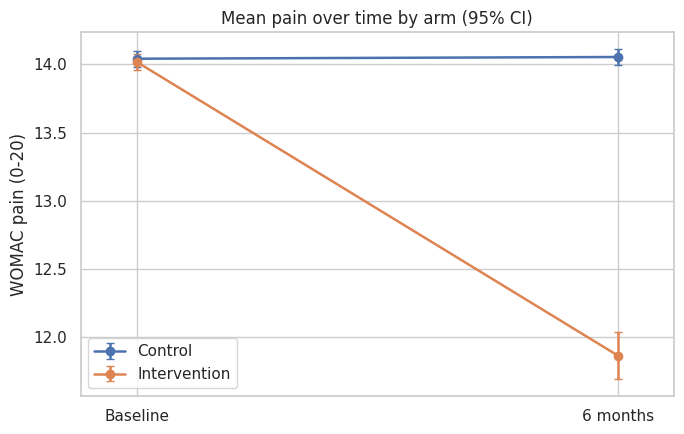

In [9]:
# headline RQ1 picture: mean pain at 0 and 6 months by arm, 95% CI
fig, ax = plt.subplots(figsize=(7, 4.5))
for a, g in cc.groupby("arm"):
    means = [g.pain_score_baseline.mean(), g.pain_score_final.mean()]
    ci95  = [1.96 * g.pain_score_baseline.sem(), 1.96 * g.pain_score_final.sem()]
    ax.errorbar([0, 6], means, yerr=ci95, marker="o", capsize=3, lw=1.8,
                color=palette[a], label=a)
ax.set_xticks([0, 6]); ax.set_xticklabels(["Baseline", "6 months"])
ax.set_xlim(-0.7, 6.7)
ax.set_ylabel("WOMAC pain (0-20)")
ax.set_title("Mean pain over time by arm (95% CI)")
ax.legend()
plt.tight_layout(); plt.show()
# error bars are tiny with >1000 per arm; flat control line vs the intervention drop is the story

### 4b. Primary ANCOVA (`final ~ arm + baseline`, HC3 robust SE)

In [10]:
# 4b. Primary ANCOVA: final ~ arm + baseline, HC3 robust SE
TERMS_PRIM=[("treatment_group","num"),("pain_score_baseline","num")]
if HAVE_SM:
    m=smf.ols("pain_score_final ~ treatment_group + pain_score_baseline",data=cc).fit(cov_type="HC3")
    b=m.params["treatment_group"]; lo,hi=m.conf_int().loc["treatment_group"]; p=m.pvalues["treatment_group"]
else:
    b,lo,hi,p,_,_,_=ols_hc3(cc,"pain_score_final",TERMS_PRIM,"treatment_group")
print(f"Adjusted mean difference (Intervention - Control): {b:+.2f} pts (95% CI {lo:+.2f} to {hi:+.2f}), p={p:.3g}")
print(f"Negative = lower (better) pain.")
print(f"\nSecondary lens - benchmark against the exercise-derived MCID ({MCID} pts):")
print(f"   point estimate {abs(b):.2f} pts -> {'EXCEEDS' if abs(b)>MCID else 'below'} MCID"
      f" ({abs(b)/MCID:.2f} x MCID)")
print(f"   whole 95% CI beyond MCID? {'yes' if min(abs(lo),abs(hi))>MCID else 'no'}"
      f"  (CI spans {abs(hi):.2f}-{abs(lo):.2f} pts = {abs(hi)/MCID:.2f}-{abs(lo)/MCID:.2f} x MCID)")
print("   NOTE: MCID derived from exercise trials; benchmark only, not a decision rule.")


Adjusted mean difference (Intervention - Control): -2.18 pts (95% CI -2.36 to -2.00), p=4.84e-125
Negative = lower (better) pain.

Secondary lens - benchmark against the exercise-derived MCID (1.6 pts):
   point estimate 2.18 pts -> EXCEEDS MCID (1.36 x MCID)
   whole 95% CI beyond MCID? yes  (CI spans 2.00-2.36 pts = 1.25-1.47 x MCID)
   NOTE: MCID derived from exercise trials; benchmark only, not a decision rule.


### 4c. Assumption checks (drive the choices above and in Step 6)

In [11]:
# 4c. Assumption checks
if HAVE_SM:
    m_cls=smf.ols("pain_score_final ~ treatment_group + pain_score_baseline",data=cc).fit()
    resid=m_cls.resid.values; Xp=m_cls.model.exog
    bp_p=sm.stats.diagnostic.het_breuschpagan(resid,Xp)[1]
    mi_=smf.ols("pain_score_final ~ treatment_group * pain_score_baseline",data=cc).fit()
    pint=mi_.pvalues["treatment_group:pain_score_baseline"]
    bint=mi_.params["treatment_group:pain_score_baseline"]; bmain=mi_.params["treatment_group"]
else:
    _,_,_,resid,Xp,_,_=ols_plain(cc,"pain_score_final",TERMS_PRIM,"treatment_group")
    bp_p=breusch_pagan(resid,Xp)
    tmp=cc.copy(); tmp["tb"]=tmp.treatment_group*tmp.pain_score_baseline
    TI=[("treatment_group","num"),("pain_score_baseline","num"),("tb","num")]
    bint,_,pint,_,_,beta_i,names_i=ols_plain(tmp,"pain_score_final",TI,"tb")
    bmain=beta_i[names_i.index("treatment_group")]
print(f"Residual skew {stats.skew(resid):.2f}, excess kurtosis {stats.kurtosis(resid):.2f}")
print(f"Breusch-Pagan p = {bp_p:.2e} -> heteroscedastic; handled by HC3 above")
print(f"Parallel-slopes (treatment x baseline) p = {pint:.2e} -> {'VIOLATED' if pint<.05 else 'ok'}")
if pint<.05:
    for q,lab in [(.25,"low"),(.5,"median"),(.75,"high")]:
        bl=cc.pain_score_baseline.quantile(q)
        print(f"   effect at {lab} baseline ({bl:.1f}): {bmain+bint*bl:+.2f} pts")
    print("   -> reported effect is an AVERAGE; heterogeneity examined under RQ2.")
print("\nNOTE: heteroscedasticity also affects the Step-3 imputation model -> MI is a")
print("      sensitivity analysis only, for both the primary and the harms outcomes.")


Residual skew 0.03, excess kurtosis 2.26
Breusch-Pagan p = 1.08e-62 -> heteroscedastic; handled by HC3 above
Parallel-slopes (treatment x baseline) p = 6.04e-27 -> VIOLATED
   effect at low baseline (13.4): -2.77 pts
   effect at median baseline (14.0): -2.21 pts
   effect at high baseline (14.8): -1.45 pts
   -> reported effect is an AVERAGE; heterogeneity examined under RQ2.

NOTE: heteroscedasticity also affects the Step-3 imputation model -> MI is a
      sensitivity analysis only, for both the primary and the harms outcomes.


### 4d. Sensitivity analyses — using the SHARED imputations from Step 3

In [12]:
# 4d. Sensitivity analyses using the SHARED imputations
TERMS_FULL=[("treatment_group","num"),("pain_score_baseline","num"),("age","num"),
            ("gender","cat"),("bmi","num"),("trial_centre","cat")]
if HAVE_SM:
    ma=smf.ols(FULL_FORM,data=cc).fit(cov_type="HC3"); la,ha=ma.conf_int().loc["treatment_group"]; ba=ma.params["treatment_group"]
else:
    ba,la,ha,_,_,_,_=ols_hc3(cc,"pain_score_final",TERMS_FULL,"treatment_group")
print(f"(a) Fully-adjusted ANCOVA: {ba:+.2f} (95% CI {la:+.2f} to {ha:+.2f})")

est,var=[],[]
for d in IMPUTED:
    if HAVE_SM:
        f2=smf.ols("pain_score_final ~ treatment_group + pain_score_baseline",data=d).fit()
        est.append(f2.params["treatment_group"]); var.append(f2.bse["treatment_group"]**2)
    else:
        bb,sse,_,_,_,_,_=ols_plain(d,"pain_score_final",TERMS_PRIM,"treatment_group")
        est.append(bb); var.append(sse**2)
q,l_,h_=rubin(est,var)
print(f"(b) MI (MAR, M={M}, shared with harms): {q:+.2f} (95% CI {l_:+.2f} to {h_:+.2f})")

bo=df.copy(); mm=bo.pain_score_final.isna(); bo.loc[mm,"pain_score_final"]=bo.loc[mm,"pain_score_baseline"]
if HAVE_SM:
    mb=smf.ols("pain_score_final ~ treatment_group + pain_score_baseline",data=bo).fit(cov_type="HC3")
    bb2=mb.params["treatment_group"]; lb,hb=mb.conf_int().loc["treatment_group"]
else:
    bb2,lb,hb,_,_,_,_=ols_hc3(bo,"pain_score_final",TERMS_PRIM,"treatment_group")
print(f"(c) BOCF conservative ITT (n={len(bo)}): {bb2:+.2f} (95% CI {lb:+.2f} to {hb:+.2f})")


# (d) plain change-score t-test - the simplest possible analysis, kept as a sanity check
i_ = cc.loc[cc.treatment_group==1, "pain_score_diff"]; c0_ = cc.loc[cc.treatment_group==0, "pain_score_diff"]
t_, p_ = stats.ttest_ind(i_, c0_, equal_var=False)
d_ = i_.mean() - c0_.mean()
se_ = np.sqrt(i_.var(ddof=1)/len(i_) + c0_.var(ddof=1)/len(c0_))
print(f"(d) Change-score Welch t-test: diff {d_:+.2f} pts (95% CI {d_-1.96*se_:+.2f} to {d_+1.96*se_:+.2f}), p={p_:.2e}")

# (e) gender-only adjustment - specifically because of the Table 1 imbalance (SMD 0.66)
if HAVE_SM:
    mg = smf.ols("pain_score_final ~ treatment_group + pain_score_baseline + gender", data=cc).fit(cov_type="HC3")
    bg = mg.params["treatment_group"]; lg, hg = mg.conf_int().loc["treatment_group"]
else:
    bg, lg, hg, _, _, _, _ = ols_hc3(cc, "pain_score_final",
                                     TERMS_PRIM+[("gender","num")], "treatment_group")
print(f"(e) Gender-adjusted ANCOVA:  {bg:+.2f} (95% CI {lg:+.2f} to {hg:+.2f})  <- checks the Table 1 gender imbalance; barely moves")

(a) Fully-adjusted ANCOVA: -2.17 (95% CI -2.36 to -1.98)


(b) MI (MAR, M=20, shared with harms): -2.16 (95% CI -2.34 to -1.98)
(c) BOCF conservative ITT (n=2500): -1.90 (95% CI -2.06 to -1.73)
(d) Change-score Welch t-test: diff +2.17 pts (95% CI +1.98 to +2.35), p=5.29e-102
(e) Gender-adjusted ANCOVA:  -2.18 (95% CI -2.37 to -1.98)  <- checks the Table 1 gender imbalance; barely moves


### 4e. Clinical significance — responder analysis (improvement >= MCID)

In [13]:
cc["responder"]=(cc.pain_score_diff>=MCID).astype(int)
r=cc.groupby("arm").responder.agg(['sum','size']); r["pct"]=(100*r["sum"]/r["size"]).round(1)
print(f"Responders (improvement >= MCID = {MCID} pts):"); print(r.to_string())

x1=int(r.loc["Intervention","sum"]); n1=int(r.loc["Intervention","size"])
x0=int(r.loc["Control","sum"]);      n0=int(r.loc["Control","size"])
rd,rl,rh=_rd_newcombe(x1,n1,x0,n0); rr,rrl,rrh=_rr_log(x1,n1,x0,n0)
_,pchi,_,_ = stats.chi2_contingency(pd.crosstab(cc.arm, cc.responder))
print(f"\nRisk difference {100*rd:+.1f} pp (95% CI {100*rl:+.1f} to {100*rh:+.1f})")
print(f"Risk ratio      {rr:.2f} (95% CI {rrl:.2f} to {rrh:.2f})")
print(f"NNT             {1/rd:.1f} (95% CI {1/rh:.1f} to {1/rl:.1f})")
print(f"chi-square p = {pchi:.2e}")

print(f"\nMCID sensitivity - responder rates across thresholds (RD with 95% CI):")
for thr in MCID_ALT:
    resp=(cc.pain_score_diff>=thr).astype(int)
    a1=resp[cc.treatment_group==1].sum(); m1=(cc.treatment_group==1).sum()
    a0=resp[cc.treatment_group==0].sum(); m0=(cc.treatment_group==0).sum()
    d,l_,h_=_rd_newcombe(a1,m1,a0,m0)
    star=" <- primary (Han 2024)" if abs(thr-MCID)<1e-9 else ""
    print(f"   >= {thr:>3.1f} pts: Int {100*a1/m1:5.1f}% vs Ctl {100*a0/m0:5.1f}% | "
          f"RD {100*d:+5.1f} pp (95% CI {100*l_:+5.1f} to {100*h_:+5.1f}){star}")


Responders (improvement >= MCID = 1.6 pts):
              sum  size   pct
arm                          
Control       142  1145  12.4
Intervention  569  1095  52.0

Risk difference +39.6 pp (95% CI +36.0 to +43.0)
Risk ratio      4.19 (95% CI 3.56 to 4.94)
NNT             2.5 (95% CI 2.3 to 2.8)
chi-square p = 1.56e-89

MCID sensitivity - responder rates across thresholds (RD with 95% CI):
   >= 1.0 pts: Int  65.2% vs Ctl  27.2% | RD +38.0 pp (95% CI +34.1 to +41.8)
   >= 1.6 pts: Int  52.0% vs Ctl  12.4% | RD +39.6 pp (95% CI +36.0 to +43.0) <- primary (Han 2024)
   >= 2.0 pts: Int  48.1% vs Ctl   9.3% | RD +38.9 pp (95% CI +35.4 to +42.2)
   >= 2.5 pts: Int  40.5% vs Ctl   3.9% | RD +36.6 pp (95% CI +33.5 to +39.7)


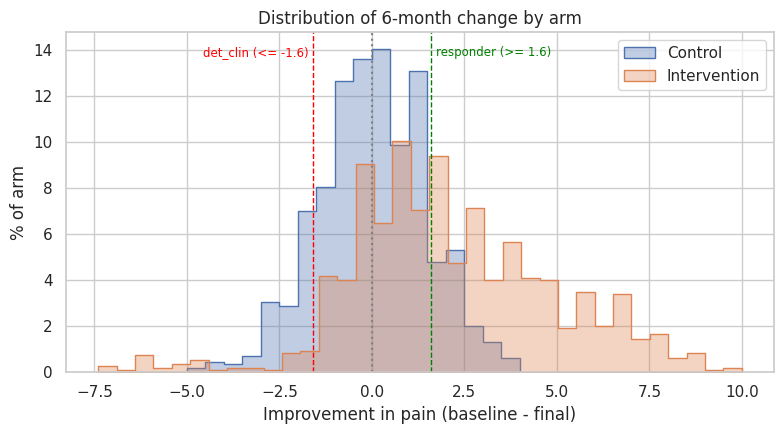

In [14]:
# what the mean difference hides: the full distribution of change, with the MCID marked
fig, ax = plt.subplots(figsize=(8, 4.5))
for a, g in cc.groupby("arm"):
    sns.histplot(g.pain_score_diff, ax=ax, color=palette[a], label=a, stat="percent",
                 element="step", common_norm=False, binwidth=0.5, alpha=.35)
ax.axvline(0, color="grey", ls=":")
ax.axvline(MCID, color="green", ls="--", lw=1)
ax.axvline(-MCID, color="red", ls="--", lw=1)
ymax = ax.get_ylim()[1]
ax.text(MCID + .12, ymax * .93, f"responder (>= {MCID})", color="green", fontsize=8.5)
ax.text(-MCID - .12, ymax * .93, f"det_clin (<= -{MCID})", color="red", fontsize=8.5, ha="right")
ax.set_xlabel("Improvement in pain (baseline - final)"); ax.set_ylabel("% of arm")
ax.set_title("Distribution of 6-month change by arm")
ax.legend()
plt.tight_layout(); plt.show()
# control is a narrow spike around 0; intervention is shifted right but with a long left tail -
# that tail is what Steps 6 and 8 chase

### 4f. Responder analysis, NRI version

Same as 4e but on all 2,500 randomised, with the 260 dropouts counted as non-responders. Intervention loses more people, so this is conservative against the intervention - doubles as a missing-data check on 4e.

In [15]:
dfr = df.copy()
dfr["responder_nri"] = (dfr.pain_score_diff >= MCID).astype(int)   # NaN >= MCID -> False, so dropouts = non-responders

print(pd.crosstab(dfr.arm, dfr.responder_nri, margins=True))
print(f"\nResponders (>= {MCID}-pt improvement, NRI, denominators = all randomised):")
print((dfr.groupby("arm")["responder_nri"].mean()*100).round(1).astype(str) + "%")

x1 = int(dfr.loc[dfr.treatment_group==1, "responder_nri"].sum()); n1 = int((dfr.treatment_group==1).sum())
x0 = int(dfr.loc[dfr.treatment_group==0, "responder_nri"].sum()); n0 = int((dfr.treatment_group==0).sum())
rd, rl, rh = _rd_newcombe(x1, n1, x0, n0); rr, rrl, rrh = _rr_log(x1, n1, x0, n0)
print(f"\nRisk difference {100*rd:+.1f} pp (95% CI {100*rl:+.1f} to {100*rh:+.1f})")
print(f"Risk ratio      {rr:.2f} (95% CI {rrl:.2f} to {rrh:.2f})")

if HAVE_SM:
    logit = smf.logit("responder_nri ~ treatment_group + pain_score_baseline", data=dfr).fit(disp=False)
    orr = np.exp(logit.params["treatment_group"]); oci = np.exp(logit.conf_int().loc["treatment_group"])
    print(f"Odds ratio (baseline-adjusted logit): {orr:.2f} (95% CI {oci[0]:.2f} to {oci[1]:.2f})")

print("\nagrees with 4e -> responder conclusion doesn't hinge on dropout handling")

responder_nri     0    1   All
arm                           
Control        1090  142  1232
Intervention    699  569  1268
All            1789  711  2500

Responders (>= 1.6-pt improvement, NRI, denominators = all randomised):
arm
Control         11.5%
Intervention    44.9%
Name: responder_nri, dtype: object

Risk difference +33.3 pp (95% CI +30.0 to +36.6)
Risk ratio      3.89 (95% CI 3.30 to 4.60)
Odds ratio (baseline-adjusted logit): 6.79 (95% CI 5.49 to 8.40)

agrees with 4e -> responder conclusion doesn't hinge on dropout handling


## Step 5 — RQ2: sub-groups

Effect modification tested with treatment x covariate interaction terms, not by comparing within-subgroup p-values. Exploratory, no multiplicity adjustment - anything found is hypothesis-generating. The per-subgroup effects below feed the Step 9 forest plot, which is display only.

In [16]:
# 5a. Interaction tests (effect modification)
def nested_F(data, y, terms_red, terms_full):
    """F test comparing nested OLS models (numpy fallback path)."""
    def rss(terms):
        X,_=_dmat(data,terms); yv=data[y].astype(float).values
        b=np.linalg.pinv(X.T@X)@X.T@yv; r=yv-X@b
        return r@r, X.shape[1]
    r_r,k_r=rss(terms_red); r_f,k_f=rss(terms_full); n=len(data)
    df1=k_f-k_r; df2=n-k_f
    F=((r_r-r_f)/df1)/(r_f/df2)
    return stats.f.sf(F,df1,df2)

BASE=[("treatment_group","num"),("pain_score_baseline","num")]
rows=[]
subgroups=[("gender","cat","Gender"),("age","num","Age"),("bmi","num","BMI"),
           ("n_current_medications","num","Medications"),
           ("trial_centre","cat","Trial centre"),("pain_score_baseline","num","Baseline pain")]
for col,kind,label in subgroups:
    d=cc.copy()
    if HAVE_SM:
        term = f"C({col})" if kind=="cat" else col
        if col=="pain_score_baseline":
            f_="pain_score_final ~ treatment_group * pain_score_baseline"
            red="pain_score_final ~ treatment_group + pain_score_baseline"
        else:
            f_=f"pain_score_final ~ treatment_group * {term} + pain_score_baseline"
            red=f"pain_score_final ~ treatment_group + {term} + pain_score_baseline"
        mf=smf.ols(f_,data=d).fit(); mr=smf.ols(red,data=d).fit()
        p=mf.compare_f_test(mr)[1]
    else:
        if kind=="cat":
            lv=sorted(d[col].dropna().unique())[1:]
            for v in lv: d[f"ix_{col}_{v}"]=d.treatment_group*(d[col]==v).astype(float)
            extra=[(f"ix_{col}_{v}","num") for v in lv]
            red=BASE+[(col,"cat")]; full=red+extra
        else:
            d[f"ix_{col}"]=d.treatment_group*d[col].astype(float)
            red=BASE if col=="pain_score_baseline" else BASE+[(col,"num")]
            full=red+[(f"ix_{col}","num")]
        p=nested_F(d,"pain_score_final",red,full)
    # interaction ESTIMATE with 95% CI (continuous covariates; CONSORT item 26)
    est_txt=""
    if kind=="num":
        d2=cc.copy(); d2["ix"]=d2.treatment_group*d2[col].astype(float)
        red=BASE if col=="pain_score_baseline" else BASE+[(col,"num")]
        bi,li,hi_,_,_,_,_=ols_hc3(d2,"pain_score_final",red+[("ix","num")],"ix")
        est_txt=f" | interaction {bi:+.3f} pts per unit (95% CI {li:+.3f} to {hi_:+.3f})"
    rows.append((label,p))
    flag="**HETEROGENEITY**" if p<0.05 else "no evidence"
    print(f"  treatment x {label:15s}: p = {p:.2e}  {flag}{est_txt}")
print("\nInteraction tests, not within-subgroup comparisons. Exploratory; no alpha adjustment.")


  treatment x Gender         : p = 8.87e-01  no evidence
  treatment x Age            : p = 8.95e-01  no evidence | interaction +0.003 pts per unit (95% CI -0.037 to +0.042)
  treatment x BMI            : p = 8.27e-01  no evidence | interaction +0.008 pts per unit (95% CI -0.071 to +0.087)
  treatment x Medications    : p = 9.46e-01  no evidence | interaction -0.003 pts per unit (95% CI -0.098 to +0.092)
  treatment x Trial centre   : p = 2.07e-21  **HETEROGENEITY**
  treatment x Baseline pain  : p = 6.04e-27  **HETEROGENEITY** | interaction +0.943 pts per unit (95% CI +0.771 to +1.115)

Interaction tests, not within-subgroup comparisons. Exploratory; no alpha adjustment.


In [17]:
# 5a (cont.) subgroup-specific effects, for display only (forest plot)
def eff_in(subset):
    if len(subset)<30: return (np.nan,)*3
    if HAVE_SM:
        mm=smf.ols("pain_score_final ~ treatment_group + pain_score_baseline",
                   data=subset).fit(cov_type="HC3")
        return mm.params["treatment_group"], *mm.conf_int().loc["treatment_group"]
    b,l,h,_,_,_,_=ols_hc3(subset,"pain_score_final",TERMS_PRIM,"treatment_group")
    return b,l,h

strata=[("Overall", cc)]
strata+=[(f"Gender={'F' if g==1 else 'M'}", cc[cc.gender==g]) for g in sorted(cc.gender.unique())]
med_age=cc.age.median(); strata+=[(f"Age<={med_age:.0f}",cc[cc.age<=med_age]),(f"Age>{med_age:.0f}",cc[cc.age>med_age])]
med_bmi=cc.bmi.median(); strata+=[(f"BMI<={med_bmi:.1f}",cc[cc.bmi<=med_bmi]),(f"BMI>{med_bmi:.1f}",cc[cc.bmi>med_bmi])]
strata+=[(f"Centre {c}",cc[cc.trial_centre==c]) for c in sorted(cc.trial_centre.unique())]
med_bp=cc.pain_score_baseline.median()
strata+=[(f"Baseline<={med_bp:.1f}",cc[cc.pain_score_baseline<=med_bp]),
         (f"Baseline>{med_bp:.1f}",cc[cc.pain_score_baseline>med_bp])]

SUB=[]
for lab,s in strata:
    b,l,h=eff_in(s); SUB.append((lab,b,l,h,len(s)))
    print(f"  {lab:16s} n={len(s):5d}  effect {b:+.2f} (95% CI {l:+.2f} to {h:+.2f})")


  Overall          n= 2240  effect -2.18 (95% CI -2.36 to -2.00)
  Gender=M         n= 1124  effect -2.16 (95% CI -2.48 to -1.85)
  Gender=F         n= 1116  effect -2.18 (95% CI -2.42 to -1.95)
  Age<=68          n= 1238  effect -2.23 (95% CI -2.47 to -1.98)
  Age>68           n= 1002  effect -2.12 (95% CI -2.38 to -1.85)
  BMI<=29.4        n= 1144  effect -2.36 (95% CI -2.60 to -2.12)
  BMI>29.4         n= 1096  effect -2.00 (95% CI -2.27 to -1.73)
  Centre 1         n=  791  effect -3.15 (95% CI -3.47 to -2.84)
  Centre 2         n=  753  effect -2.15 (95% CI -2.43 to -1.86)
  Centre 3         n=  696  effect -1.04 (95% CI -1.33 to -0.76)
  Baseline<=14.0   n= 1207  effect -2.80 (95% CI -3.03 to -2.57)
  Baseline>14.0    n= 1033  effect -1.45 (95% CI -1.72 to -1.18)


### 5b. Dose-response for benefit (intervention arm only)

Engagement and activity are post-randomisation and self-selected: association, not causation. Informs intervention design, not efficacy claims.

In [18]:
# 5b. Dose-response for benefit: engagement / activity vs pain IMPROVEMENT
ivb = df[(df.treatment_group==1) & df.pain_score_final.notna()].copy()
print(f"Intervention arm with outcome: n={len(ivb)}\n")
for var,lab in [("app_interactions","App engagement"),("physical_activity","Physical activity")]:
    s=ivb.dropna(subset=[var])
    r,pr=stats.pearsonr(s[var], s.pain_score_diff)
    rho,prho=stats.spearmanr(s[var], s.pain_score_diff)
    # adjusted for baseline pain (partial association)
    if HAVE_SM:
        mm=smf.ols(f"pain_score_diff ~ {var} + pain_score_baseline + age + C(gender) + bmi + C(trial_centre)",
                   data=s).fit(cov_type="HC3")
        b=mm.params[var]; lo,hi=mm.conf_int().loc[var]
    else:
        T=[(var,"num"),("pain_score_baseline","num"),("age","num"),
           ("gender","cat"),("bmi","num"),("trial_centre","cat")]
        b,lo,hi,_,_,_,_=ols_hc3(s,"pain_score_diff",T,var)
    sd=s[var].std()
    print(f"{lab}:")
    print(f"   unadjusted r={r:.3f} (p={pr:.2e}) | Spearman rho={rho:.3f}")
    print(f"   ADJUSTED slope {b:+.4f} per unit (95% CI {lo:+.4f} to {hi:+.4f})"
          f"  -> {b*sd:+.2f} pts improvement per +1 SD ({sd:.3f})")
print("\nEXPLORATORY / non-randomised: associations only, no causal claim.")


Intervention arm with outcome: n=1095

App engagement:
   unadjusted r=0.544 (p=1.77e-85) | Spearman rho=0.678
   ADJUSTED slope +0.1953 per unit (95% CI +0.1694 to +0.2212)  -> +1.50 pts improvement per +1 SD (7.688)
Physical activity:
   unadjusted r=0.531 (p=1.21e-80) | Spearman rho=0.690
   ADJUSTED slope +4.9513 per unit (95% CI +4.1451 to +5.7575)  -> +1.46 pts improvement per +1 SD (0.294)

EXPLORATORY / non-randomised: associations only, no causal claim.


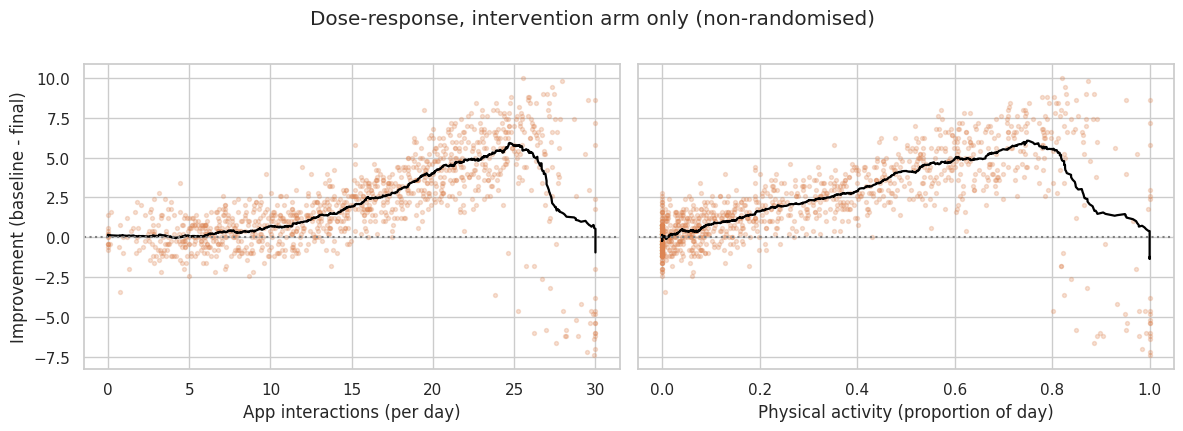

In [19]:
# scatter + rolling mean, one panel per exposure
fig, axes = plt.subplots(1, 2, figsize=(12, 4.3), sharey=True)
for ax, var, lab in [(axes[0], "app_interactions", "App interactions (per day)"),
                     (axes[1], "physical_activity", "Physical activity (proportion of day)")]:
    ax.scatter(ivb[var], ivb.pain_score_diff, s=8, alpha=.25, color=palette["Intervention"])
    srt = ivb.dropna(subset=[var]).sort_values(var)
    ax.plot(srt[var], srt.pain_score_diff.rolling(80, center=True, min_periods=25).mean(),
            color="black", lw=1.6)
    ax.axhline(0, color="grey", ls=":")
    ax.set_xlabel(lab)
axes[0].set_ylabel("Improvement (baseline - final)")
fig.suptitle("Dose-response, intervention arm only (non-randomised)", y=1.0)
plt.tight_layout(); plt.show()
# note the right-hand panel: improvement climbs with activity then collapses past ~0.8 -
# same cluster Step 8 pins down formally

### 5c. Blinding check

Same wearable in both arms and the control app kept psychoeducation, so guesses should sit at chance. If blinding failed, expectation effects could be inflating RQ1.

In [20]:
n_correct = (df.treatment_guess == df.treatment_group).sum()
rate = n_correct / len(df)
p_binom = stats.binomtest(n_correct, len(df), 0.5).pvalue
print(pd.crosstab(df.arm, df.treatment_guess.map({0: "guessed control", 1: "guessed intervention"})))
print(f"\nOverall correct-guess rate: {rate:.1%} (chance = 50%); binomial test vs 0.5: p = {p_binom:.3f}")

# break it down by arm - overall 50% could hide the two arms mis-guessing in opposite ways
for g, sub in df.groupby("arm"):
    cr = (sub.treatment_guess == sub.treatment_group).mean()
    print(f"   {g:12s}: correct {cr:.1%}  (n={len(sub)})")
chi2, p_arm, _, _ = stats.chi2_contingency(pd.crosstab(df.treatment_group, df.treatment_guess))
print(f"Guess x arm association: chi-square p = {p_arm:.3f}")
print("-> at chance overall and within each arm: blinding held.")

treatment_guess  guessed control  guessed intervention
arm                                                   
Control                      612                   620
Intervention                 610                   658

Overall correct-guess rate: 50.8% (chance = 50%); binomial test vs 0.5: p = 0.435
   Control     : correct 49.7%  (n=1232)
   Intervention: correct 51.9%  (n=1268)
Guess x arm association: chi-square p = 0.457
-> at chance overall and within each arm: blinding held.


## Step 6 — RQ3: pain deterioration

No adverse-event log was collected, so harms are assessed non-systematically from the trial data (CONSORT item 15 permits this if declared).

- `det_any`  = any worsening (`pain_score_diff < 0`)
- `det_clin` = worsening >= MCID (1.6)

The MCID is improvement-derived; transition-method studies give different thresholds for deterioration - one more reason 6b rescans across thresholds.

In [21]:
cc["det_any"]  = (cc.pain_score_diff < 0).astype(int)
cc["det_clin"] = (cc.pain_score_diff <= -MCID).astype(int)

# --- assumption checks BEFORE choosing the tests ---
def expected_min(x1,n1,x0,n0):
    obs=np.array([[x1,n1-x1],[x0,n0-x0]]); return stats.chi2_contingency(obs,correction=False)[3].min()
for lab,col in [("any","det_any"),("clinical","det_clin")]:
    x1=cc.loc[cc.treatment_group==1,col].sum(); n1=(cc.treatment_group==1).sum()
    x0=cc.loc[cc.treatment_group==0,col].sum(); n0=(cc.treatment_group==0).sum()
    print(f"[{lab:8s}] min expected cell {expected_min(x1,n1,x0,n0):7.1f} -> "
          f"{'chi-square OK' if expected_min(x1,n1,x0,n0)>=5 else 'USE FISHER'} | "
          f"events int={x1}, ctl={x0} -> RR approx {'OK' if min(x1,x0)>=10 else 'SPARSE->bootstrap'}")


[any     ] min expected cell   370.5 -> chi-square OK | events int=198, ctl=560 -> RR approx OK
[clinical] min expected cell    91.4 -> chi-square OK | events int=44, ctl=143 -> RR approx OK


In [22]:
def _wilson(x,n,z=1.96):
    if n==0: return (np.nan,np.nan)
    p=x/n; d=1+z*z/n; ctr=(p+z*z/(2*n))/d; h=z*np.sqrt(p*(1-p)/n+z*z/(4*n*n))/d
    return ctr-h, ctr+h
def risk_diff(x1,n1,x0,n0,z=1.96):                    # Newcombe hybrid-score CI
    p1,p0=x1/n1,x0/n0; l1,u1=_wilson(x1,n1,z); l0,u0=_wilson(x0,n0,z); rd=p1-p0
    return rd, rd-np.sqrt((p1-l1)**2+(u0-p0)**2), rd+np.sqrt((u1-p1)**2+(p0-l0)**2)
def risk_ratio(x1,n1,x0,n0,z=1.96):
    a,b=(x1,x0) if (x1>0 and x0>0) else (x1+.5,x0+.5)
    n1c,n0c=(n1,n0) if (x1>0 and x0>0) else (n1+1,n0+1)
    rr=(a/n1c)/(b/n0c); se=np.sqrt(1/a-1/n1c+1/b-1/n0c)
    return rr, np.exp(np.log(rr)-z*se), np.exp(np.log(rr)+z*se)

def harm_table(data,col,label):
    x1=int(data.loc[data.treatment_group==1,col].sum()); n1=int((data.treatment_group==1).sum())
    x0=int(data.loc[data.treatment_group==0,col].sum()); n0=int((data.treatment_group==0).sum())
    rd,rl,rh=risk_diff(x1,n1,x0,n0); rr,rrl,rrh=risk_ratio(x1,n1,x0,n0)
    ct=np.array([[x1,n1-x1],[x0,n0-x0]])
    if (stats.chi2_contingency(ct,correction=False)[3]>=5).all():
        _,p,_,_=stats.chi2_contingency(ct,correction=False); test="chi-square"
    else:
        _,p=stats.fisher_exact(ct); test="Fisher"
    print(f"=== {label} ===")
    print(f"  Intervention {x1}/{n1} = {100*x1/n1:5.1f}%   Control {x0}/{n0} = {100*x0/n0:5.1f}%")
    print(f"  Risk difference (Int-Ctl): {rd:+.3f} (95% CI {rl:+.3f} to {rh:+.3f})")
    print(f"  Risk ratio      (Int/Ctl): {rr:.3f} (95% CI {rrl:.3f} to {rrh:.3f})")
    print(f"  {test} p={p:.3g}   (RD>0 / RR>1 would mean MORE harm in intervention)\n")
    return dict(x1=x1,n1=n1,x0=x0,n0=n0,rd=rd,rdl=rl,rdh=rh,rr=rr)

res_any  = harm_table(cc,"det_any", "Any worsening (final > baseline)")
res_clin = harm_table(cc,"det_clin", f"Clinically important worsening (>= {MCID:.1f} pts)")


=== Any worsening (final > baseline) ===
  Intervention 198/1095 =  18.1%   Control 560/1145 =  48.9%
  Risk difference (Int-Ctl): -0.308 (95% CI -0.344 to -0.271)
  Risk ratio      (Int/Ctl): 0.370 (95% CI 0.322 to 0.425)
  chi-square p=1.33e-53   (RD>0 / RR>1 would mean MORE harm in intervention)

=== Clinically important worsening (>= 1.6 pts) ===
  Intervention 44/1095 =   4.0%   Control 143/1145 =  12.5%
  Risk difference (Int-Ctl): -0.085 (95% CI -0.107 to -0.062)
  Risk ratio      (Int/Ctl): 0.322 (95% CI 0.232 to 0.446)
  chi-square p=4.32e-13   (RD>0 / RR>1 would mean MORE harm in intervention)



### 6b. Harms sensitivity — reusing the SAME shared imputations (item 28)

In [23]:
# (a) MI - identical imputations as the primary analysis (Step 3)
for lab,thr in [("Any worsening",0),(f"Clinical (>={MCID:.1f})",MCID)]:
    e,v=[],[]
    for d in IMPUTED:
        det=(d.pain_score_diff<0).astype(int) if thr==0 else (d.pain_score_diff<=-thr).astype(int)
        x1=det[d.treatment_group==1].sum(); n1=(d.treatment_group==1).sum()
        x0=det[d.treatment_group==0].sum(); n0=(d.treatment_group==0).sum()
        p1,p0=x1/n1,x0/n0; e.append(p1-p0); v.append(p1*(1-p1)/n1+p0*(1-p0)/n0)
    q,l_,h_=rubin(e,v)
    print(f"(a) MI RD {lab:18s}: {q:+.3f} (95% CI {l_:+.3f} to {h_:+.3f})")

# (b) worst / best-case bounding - the key check for DIFFERENTIAL attrition
print()
for lab,thr in [("Any worsening",0),(f"Clinical (>={MCID:.1f})",MCID)]:
    print(f"(b) Bounding - {lab}:")
    for sc,iv_,cv_ in [("worst (vs intervention)",1,0),("best  (for intervention)",0,1)]:
        d3=df.copy(); obs=d3.pain_score_final.notna(); det=pd.Series(index=d3.index,dtype=float)
        det[obs]=((d3.loc[obs,"pain_score_diff"]<0).astype(int) if thr==0
                  else (d3.loc[obs,"pain_score_diff"]<=-thr).astype(int))
        m_=~obs; det[m_&(d3.treatment_group==1)]=iv_; det[m_&(d3.treatment_group==0)]=cv_
        det=det.astype(int)
        x1=det[d3.treatment_group==1].sum(); n1=(d3.treatment_group==1).sum()
        x0=det[d3.treatment_group==0].sum(); n0=(d3.treatment_group==0).sum()
        rd,l_,h_=risk_diff(x1,n1,x0,n0)
        print(f"      {sc}: RD {rd:+.3f} (95% CI {l_:+.3f} to {h_:+.3f})")
    print()

# (c) threshold sensitivity
print("(c) Threshold sensitivity (complete case):")
for thr,name in [(0.,"any worsening")]+[(t,f">= {t} pts") for t in MCID_ALT]:
    col=(cc.pain_score_diff<0).astype(int) if thr==0 else (cc.pain_score_diff<=-thr).astype(int)
    x1=col[cc.treatment_group==1].sum(); n1=(cc.treatment_group==1).sum()
    x0=col[cc.treatment_group==0].sum(); n0=(cc.treatment_group==0).sum()
    rd,l_,h_=risk_diff(x1,n1,x0,n0)
    print(f"      {name+(' <- primary' if abs(thr-MCID)<1e-9 else ''):22s}: Int {100*x1/n1:4.1f}% vs Ctl {100*x0/n0:4.1f}% | RD {rd:+.3f} ({l_:+.3f} to {h_:+.3f})")


(a) MI RD Any worsening     : -0.310 (95% CI -0.347 to -0.273)
(a) MI RD Clinical (>=1.6)  : -0.091 (95% CI -0.114 to -0.067)

(b) Bounding - Any worsening:
      worst (vs intervention): RD -0.162 (95% CI -0.199 to -0.124)
      best  (for intervention): RD -0.369 (95% CI -0.403 to -0.334)

(b) Bounding - Clinical (>=1.6):
      worst (vs intervention): RD +0.055 (95% CI +0.028 to +0.082)
      best  (for intervention): RD -0.152 (95% CI -0.176 to -0.128)

(c) Threshold sensitivity (complete case):
      any worsening         : Int 18.1% vs Ctl 48.9% | RD -0.308 (-0.344 to -0.271)
      >= 1.0 pts            : Int  8.6% vs Ctl 26.5% | RD -0.179 (-0.209 to -0.148)
      >= 1.6 pts <- primary : Int  4.0% vs Ctl 12.5% | RD -0.085 (-0.107 to -0.062)
      >= 2.0 pts            : Int  3.6% vs Ctl  9.3% | RD -0.057 (-0.077 to -0.037)
      >= 2.5 pts            : Int  2.7% vs Ctl  4.7% | RD -0.020 (-0.036 to -0.004)


## Step 7 — RQ3: medication use

Single count, no baseline, so it cannot show treatment-induced change - treated as a care-seeking / co-intervention proxy (as in MOVES 2015, NAXOZOL 2020). Test chosen after the shape check below.

In [24]:
i_=df.loc[df.treatment_group==1,"n_current_medications"]; c_=df.loc[df.treatment_group==0,"n_current_medications"]
print(f"Assumption check - skew: int {stats.skew(i_):.2f}, ctl {stats.skew(c_):.2f} | "
      f"Levene equal-spread p={stats.levene(i_,c_).pvalue:.3f}")
print("  similar shape & spread -> Mann-Whitney readable as a median/location comparison\n")
for a,g in df.groupby("arm"):
    q1,q2,q3=g.n_current_medications.quantile([.25,.5,.75])
    print(f"{a:12s}: median {q2:.0f} (IQR {q1:.0f}-{q3:.0f}), mean {g.n_current_medications.mean():.2f}, n={len(g)}")
u,p=stats.mannwhitneyu(i_,c_,alternative="two-sided")
# effect size with CI: Hodges-Lehmann median difference (bootstrap CI) + mean difference
rng=np.random.default_rng(42)
hl=np.median([a-b for a in i_.sample(min(400,len(i_)),random_state=1)
                  for b in c_.sample(min(400,len(c_)),random_state=2)])
bs=[]
for _ in range(1000):
    bs.append(i_.sample(len(i_),replace=True,random_state=int(rng.integers(1e9))).mean()
              - c_.sample(len(c_),replace=True,random_state=int(rng.integers(1e9))).mean())
md=i_.mean()-c_.mean(); lo,hi=np.percentile(bs,[2.5,97.5])
print(f"\nMann-Whitney U={u:.0f}, p={p:.3g}")
print(f"Mean difference (Int-Ctl): {md:+.3f} medications (95% CI {lo:+.3f} to {hi:+.3f})")
print(f"Hodges-Lehmann median difference: {hl:+.1f}")
print("CI includes 0 -> no evidence of a between-arm difference in medication use.")


Assumption check - skew: int 0.20, ctl 0.25 | Levene equal-spread p=0.244
  similar shape & spread -> Mann-Whitney readable as a median/location comparison

Control     : median 4 (IQR 2-5), mean 3.61, n=1232
Intervention: median 4 (IQR 2-5), mean 3.66, n=1268



Mann-Whitney U=792038, p=0.539
Mean difference (Int-Ctl): +0.050 medications (95% CI -0.096 to +0.201)
Hodges-Lehmann median difference: +0.0
CI includes 0 -> no evidence of a between-arm difference in medication use.


## Step 8 — RQ3: physical activity (within-arm only)

Activity exists only in the intervention arm, so there is no randomised comparison and this cannot support a between-arm harm claim. Question instead: within the arm, does more activity associate with deterioration (overexertion)? Exploratory, reverse causation possible.

In [25]:
iv = df[(df.treatment_group==1) & df.pain_score_final.notna()].copy()
iv["det_any"]  = (iv.pain_score_diff < 0).astype(int)
iv["det_clin"] = (iv.pain_score_diff <= -MCID).astype(int)
print(f"Intervention arm with outcome and activity data: n={iv.physical_activity.notna().sum()}")
print(f"Physical activity: mean {iv.physical_activity.mean():.3f}, median {iv.physical_activity.median():.3f}, "
      f"max {iv.physical_activity.max():.3f}\n")

# --- 8a. Tertiles (retained for comparability, but see the caveat below) ---
iv["pa_tertile"]=pd.qcut(iv.physical_activity,3,labels=["Low","Mid","High"])
tab=iv.groupby("pa_tertile",observed=True).agg(
        n=("det_clin","size"), any_n=("det_any","sum"),
        any_pct=("det_any",lambda s:100*s.mean()),
        clin_n=("det_clin","sum"), clin_pct=("det_clin",lambda s:100*s.mean())).round(1)
tab["mild_only"]=tab.any_n-tab.clin_n
tab["pct_of_worseners_severe"]=(100*tab.clin_n/tab.any_n).round(1)
print("8a. Deterioration by activity tertile:"); print(tab.to_string())
cut=iv.physical_activity.quantile([1/3,2/3]).values
print(f"\n    Tertile cut-points: {cut[0]:.3f} and {cut[1]:.3f}")
print("    NOTE the anomaly: in the High tertile almost every participant who worsened at all")
print("    worsened by >= MCID (see pct_of_worseners_severe), whereas in the Low tertile most")
print("    worsening is trivial. Worsening is not just MORE common at high activity - it is")
print("    QUALITATIVELY different (rare but severe). Steps 8b-8c locate the cause.")

# --- 8b. Bimodality check: is the high-activity group two populations? ---
print("\n8b. Distribution of pain change in the HIGH tertile (is it bimodal?):")
hi=iv[iv.pa_tertile=="High"]
h,edges=np.histogram(hi.pain_score_diff,bins=np.arange(-8,11,1))
for cnt,e in zip(h,edges):
    print(f"      {e:+5.0f} to {e+1:+5.0f}: {'#'*int(cnt/2)} {cnt}")
print("      -> a separate cluster of severe worseners, distinct from the main improving mode.")


Intervention arm with outcome and activity data: n=1095
Physical activity: mean 0.327, median 0.248, max 1.000

8a. Deterioration by activity tertile:
              n  any_n  any_pct  clin_n  clin_pct  mild_only  pct_of_worseners_severe
pa_tertile                                                                           
Low         365    143     39.2      11       3.0        132                      7.7
Mid         365     21      5.8       1       0.3         20                      4.8
High        365     34      9.3      32       8.8          2                     94.1

    Tertile cut-points: 0.094 and 0.458
    NOTE the anomaly: in the High tertile almost every participant who worsened at all
    worsened by >= MCID (see pct_of_worseners_severe), whereas in the Low tertile most
    worsening is trivial. Worsening is not just MORE common at high activity - it is
    QUALITATIVELY different (rare but severe). Steps 8b-8c locate the cause.

8b. Distribution of pain change in the HI

In [26]:
# --- 8c. Threshold scan: where does harm actually begin? ---
print("8c. Severe worsening by activity band (scanning for a threshold):")
for lo in np.arange(0.0,1.0,0.10):
    g=iv[(iv.physical_activity>=lo)&(iv.physical_activity<lo+0.10)]
    if len(g)==0: continue
    print(f"      PA {lo:.2f}-{lo+0.10:.2f}: n={len(g):4d}  severe worsening {100*g.det_clin.mean():5.1f}%"
          f"  mean change {g.pain_score_diff.mean():+.2f}")

PA_THRESHOLD = 0.80
a=iv[iv.physical_activity> PA_THRESHOLD]; b=iv[iv.physical_activity<=PA_THRESHOLD]
x1=int(a.det_clin.sum()); n1=len(a); x0=int(b.det_clin.sum()); n0=len(b)
rd,rl,rh=_rd_newcombe(x1,n1,x0,n0); rr,rrl,rrh=_rr_log(x1,n1,x0,n0)
print(f"\n    THRESHOLD EFFECT (activity > {PA_THRESHOLD} vs <= {PA_THRESHOLD}), severe worsening:")
print(f"      above: {x1}/{n1} = {100*x1/n1:.1f}%   at or below: {x0}/{n0} = {100*x0/n0:.1f}%")
print(f"      Risk difference {rd:+.3f} (95% CI {rl:+.3f} to {rh:+.3f})")
print(f"      Risk ratio      {rr:.1f} (95% CI {rrl:.1f} to {rrh:.1f})")
print(f"    -> the tertile analysis diluted this: only "
      f"{100*(iv[iv.pa_tertile=='High'].physical_activity>PA_THRESHOLD).mean():.0f}% of the High tertile is above the threshold.")

# --- 8d. Adjusted model with a quadratic term (allows the non-linear shape) ---
sub=iv.dropna(subset=["physical_activity"]).copy()
sub["pa_c"]=sub.physical_activity-sub.physical_activity.mean(); sub["pa_c2"]=sub.pa_c**2
if HAVE_SM:
    lin =smf.logit("det_clin ~ pa_c + pain_score_baseline + age + C(gender) + bmi + C(trial_centre)",data=sub).fit(disp=0)
    quad=smf.logit("det_clin ~ pa_c + pa_c2 + pain_score_baseline + age + C(gender) + bmi + C(trial_centre)",data=sub).fit(disp=0)
    pq=quad.pvalues["pa_c2"]; lr_p=stats.chi2.sf(2*(quad.llf-lin.llf),1)
    print(f"\n8d. Curvature (quadratic) term p = {pq:.3g}; LR test linear vs quadratic p = {lr_p:.3g}")
else:
    print("\n8d. (quadratic model requires statsmodels; threshold analysis above is the key result)")

# --- 8e. PLAUSIBILITY of the activity variable itself ---
pa=iv.physical_activity
print(f"\n8e. Plausibility check on the activity measure:")
print(f"      active >50% of waking hours: {(pa>0.5).sum():4d} ({100*(pa>0.5).mean():.1f}%)")
print(f"      active >80% of waking hours: {(pa>0.8).sum():4d} ({100*(pa>0.8).mean():.1f}%)")
print(f"      active 100% of waking hours: {(pa==1.0).sum():4d}")
print("      Sustained activity above ~80% of waking hours is not physiologically plausible in")
print("      adults aged 60-75 with hip/knee OA. The high-risk cluster may therefore reflect a")
print("      DATA ARTEFACT rather than a real overexertion effect - report BOTH readings.")
print("\n    EXPLORATORY: non-randomised and open to reverse causation.")


8c. Severe worsening by activity band (scanning for a threshold):
      PA 0.00-0.10: n= 369  severe worsening   3.0%  mean change +0.19
      PA 0.10-0.20: n= 127  severe worsening   0.8%  mean change +1.13
      PA 0.20-0.30: n=  89  severe worsening   0.0%  mean change +1.96
      PA 0.30-0.40: n=  92  severe worsening   0.0%  mean change +2.64
      PA 0.40-0.50: n=  80  severe worsening   0.0%  mean change +3.42
      PA 0.50-0.60: n=  91  severe worsening   0.0%  mean change +4.63
      PA 0.60-0.70: n=  90  severe worsening   0.0%  mean change +4.84
      PA 0.70-0.80: n=  68  severe worsening   0.0%  mean change +6.18
      PA 0.80-0.90: n=  54  severe worsening  18.5%  mean change +4.47
      PA 0.90-1.00: n=  18  severe worsening  61.1%  mean change -1.72

    THRESHOLD EFFECT (activity > 0.8 vs <= 0.8), severe worsening:
      above: 32/89 = 36.0%   at or below: 12/1006 = 1.2%
      Risk difference +0.348 (95% CI +0.255 to +0.451)
      Risk ratio      30.1 (95% CI 16.1 to 5

## Step 9 — Figures

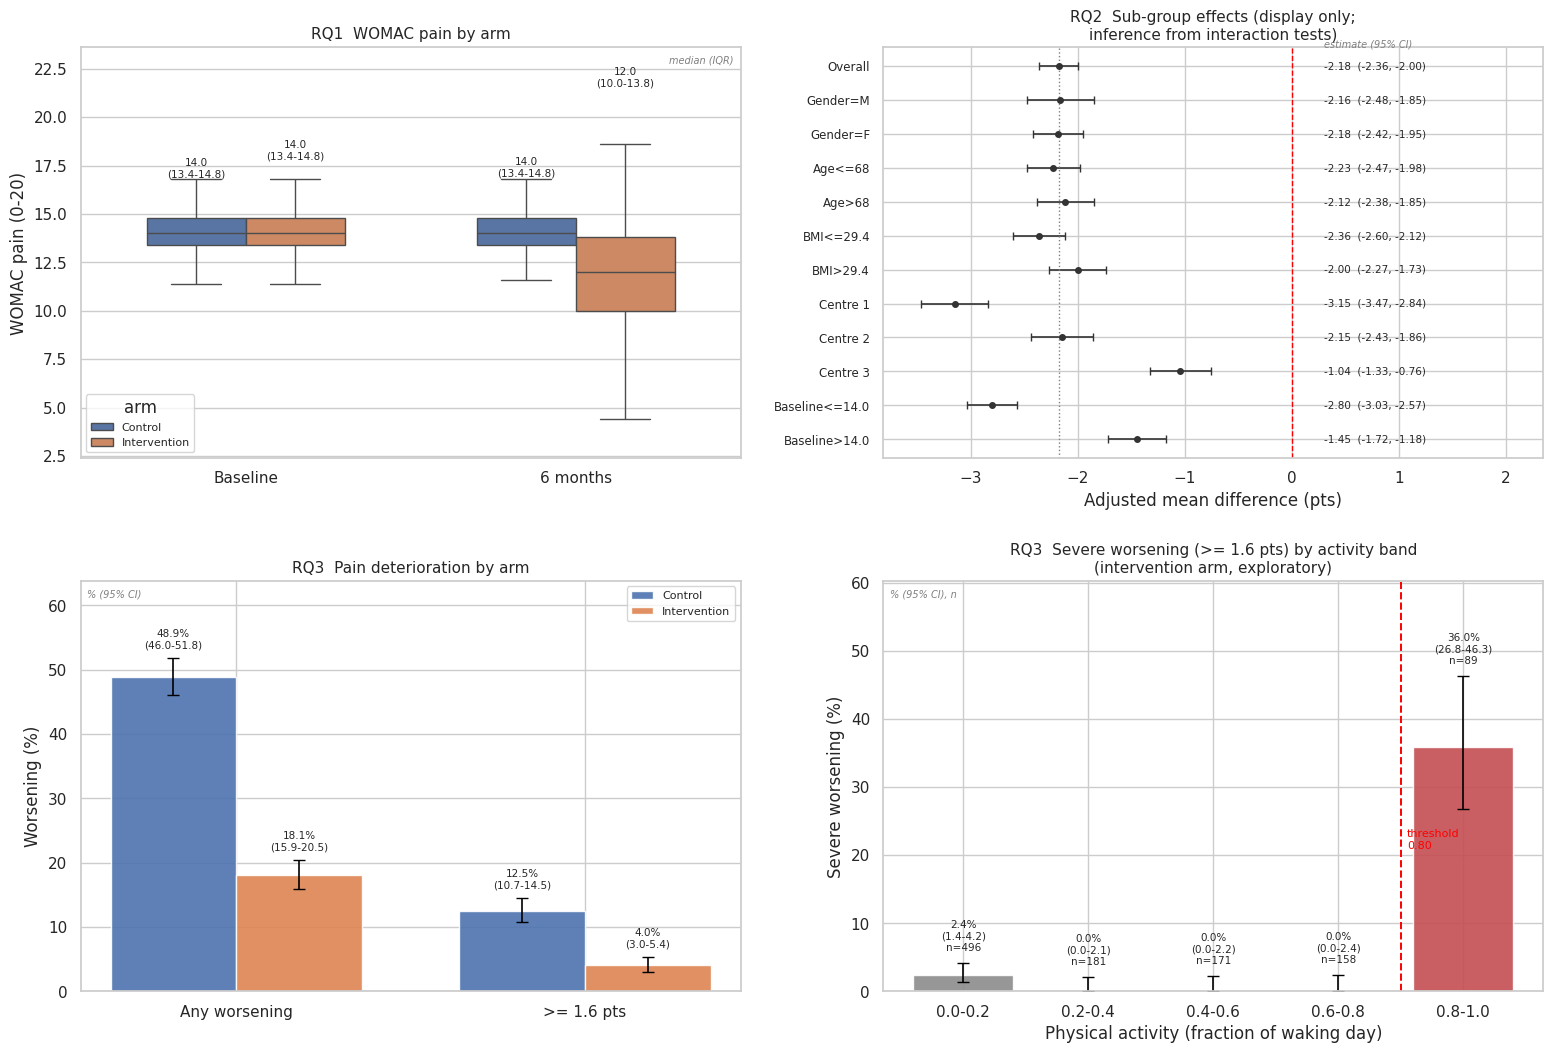

In [27]:
fig,axes=plt.subplots(2,2,figsize=(16,11))
ANN=dict(fontsize=7.5, family="DejaVu Sans")

# ============ (1) RQ1 pain by arm and timepoint (annotate median + IQR) ============
long=cc.melt(id_vars="arm",value_vars=["pain_score_baseline","pain_score_final"],
             var_name="time",value_name="pain")
long["time"]=long.time.map({"pain_score_baseline":"Baseline","pain_score_final":"6 months"})
HUE=["Control","Intervention"]
sns.boxplot(data=long,x="time",y="pain",hue="arm",hue_order=HUE,palette=palette,
            ax=axes[0,0],showfliers=False,width=.6)
axes[0,0].set_title("RQ1  WOMAC pain by arm",fontsize=11)
axes[0,0].set_xlabel(""); axes[0,0].set_ylabel("WOMAC pain (0-20)")
# annotate median (IQR) above each box, alternating height to avoid collisions
for xi,tp in enumerate(["Baseline","6 months"]):
    for hi_,arm_ in enumerate(HUE):
        v=long[(long.time==tp)&(long.arm==arm_)].pain
        med=v.median(); q1,q3=v.quantile([.25,.75]); top=v.quantile(.98)
        xpos=xi+(-0.15 if hi_==0 else 0.15)
        axes[0,0].text(xpos, top+0.6+(0.9 if hi_ else 0),
                       f"{med:.1f}\n({q1:.1f}-{q3:.1f})",
                       ha="center",va="bottom",**ANN)
axes[0,0].set_ylim(long.pain.min()-1, long.pain.max()+3.6)
axes[0,0].legend(title="arm",loc="lower left",fontsize=8)
axes[0,0].text(0.99,0.98,"median (IQR)",transform=axes[0,0].transAxes,
               ha="right",va="top",fontsize=7,style="italic",color="grey")

# ============ (2) RQ2 forest plot (annotate estimate + CI on the right) ============
labs=[s[0] for s in SUB][::-1]; bs=[s[1] for s in SUB][::-1]
los=[s[2] for s in SUB][::-1]; his=[s[3] for s in SUB][::-1]
ypos=np.arange(len(labs))
axes[0,1].errorbar(bs,ypos,xerr=[np.array(bs)-np.array(los),np.array(his)-np.array(bs)],
                   fmt="o",color="#333333",capsize=3,ms=4,lw=1.2)
axes[0,1].axvline(0,color="red",ls="--",lw=1)
axes[0,1].axvline(bs[-1],color="grey",ls=":",lw=1)
axes[0,1].set_yticks(ypos); axes[0,1].set_yticklabels(labs,fontsize=8.5)
axes[0,1].set_xlabel("Adjusted mean difference (pts)")
axes[0,1].set_title("RQ2  Sub-group effects (display only;\ninference from interaction tests)",fontsize=11)
xmin=min(los)-0.35
axes[0,1].set_xlim(xmin, 2.35)                       # room on the right for labels
for y,b,l,h in zip(ypos,bs,los,his):
    axes[0,1].text(0.30, y, f"{b:+.2f}  ({l:+.2f}, {h:+.2f})",
                   ha="left",va="center",**ANN)
axes[0,1].text(0.30, len(labs)-0.35, "estimate (95% CI)",
               ha="left",va="center",fontsize=7,style="italic",color="grey")

# ============ (3) RQ3 deterioration by arm (annotate % + CI) ============
labels=["Any worsening",f">= {MCID:.1f} pts"]; res=[res_any,res_clin]
x=np.arange(2); w=.36
maxtop=0
for grp,shift in [("Control",-w/2),("Intervention",+w/2)]:
    props,er,txt=[],[],[]
    for r in res:
        xx=r["x1"] if grp=="Intervention" else r["x0"]
        nn=r["n1"] if grp=="Intervention" else r["n0"]
        l_,h_=_wilson_ci(xx,nn); pp=xx/nn
        props.append(100*pp); er.append([100*(pp-l_),100*(h_-pp)])
        txt.append(f"{100*pp:.1f}%\n({100*l_:.1f}-{100*h_:.1f})")
    er=np.array(er).T
    axes[1,0].bar(x+shift,props,w,label=grp,color=palette[grp],alpha=.9)
    axes[1,0].errorbar(x+shift,props,yerr=er,fmt="none",ecolor="black",capsize=4,lw=1.2)
    for xi,(p_,e_,t_) in enumerate(zip(props,er[1],txt)):
        axes[1,0].text(xi+shift, p_+e_+1.2, t_, ha="center",va="bottom",**ANN)
        maxtop=max(maxtop,p_+e_)
axes[1,0].set_xticks(x); axes[1,0].set_xticklabels(labels)
axes[1,0].set_ylabel("Worsening (%)"); axes[1,0].set_ylim(0,maxtop+12)
axes[1,0].set_title("RQ3  Pain deterioration by arm",fontsize=11)
axes[1,0].legend(loc="upper right",fontsize=8)
axes[1,0].text(0.01,0.98,"% (95% CI)",transform=axes[1,0].transAxes,
               ha="left",va="top",fontsize=7,style="italic",color="grey")

# ============ (4) RQ3 severe worsening by activity band (annotate % + CI + n) ============
bands=[(0.0,0.2),(0.2,0.4),(0.4,0.6),(0.6,0.8),(0.8,1.01)]
lbl,prop,err,ns,txt=[],[],[],[],[]
for lo_,hi_ in bands:
    g=iv[(iv.physical_activity>=lo_)&(iv.physical_activity<hi_)]
    if len(g)==0: continue
    xx=int(g.det_clin.sum()); nn=len(g); pp=xx/nn
    cl,ch=_wilson_ci(xx,nn)
    lbl.append(f"{lo_:.1f}-{min(hi_,1.0):.1f}"); prop.append(100*pp)
    err.append([100*(pp-cl),100*(ch-pp)]); ns.append(nn)
    txt.append(f"{100*pp:.1f}%\n({100*cl:.1f}-{100*ch:.1f})\nn={nn}")
err=np.array(err).T
cols=["#8C8C8C"]*(len(lbl)-1)+["#C44E52"]
axes[1,1].bar(range(len(lbl)),prop,color=cols,alpha=.9)
axes[1,1].errorbar(range(len(lbl)),prop,yerr=err,fmt="none",ecolor="black",capsize=4,lw=1.2)
for k,(p_,e_,t_) in enumerate(zip(prop,err[1],txt)):
    axes[1,1].text(k, p_+e_+1.5, t_, ha="center",va="bottom",**ANN)
axes[1,1].axvline(3.5,color="red",ls="--",lw=1.4)
axes[1,1].text(3.55,max(prop)*0.62,f"threshold\n{PA_THRESHOLD:.2f}",color="red",
               fontsize=8,ha="left",va="center")
axes[1,1].set_xticks(range(len(lbl))); axes[1,1].set_xticklabels(lbl)
axes[1,1].set_ylim(0,max(np.array(prop)+err[1])+14)
axes[1,1].set_title(f"RQ3  Severe worsening (>= {MCID:.1f} pts) by activity band\n"
                    "(intervention arm, exploratory)",fontsize=11)
axes[1,1].set_xlabel("Physical activity (fraction of waking day)")
axes[1,1].set_ylabel("Severe worsening (%)")
axes[1,1].text(0.01,0.98,"% (95% CI), n",transform=axes[1,1].transAxes,
               ha="left",va="top",fontsize=7,style="italic",color="grey")

plt.tight_layout(pad=2.0)
plt.savefig("fig_integrated_analysis.png",dpi=200,bbox_inches="tight"); plt.show()
